# Import libraries


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.ion()


import mne
mne.set_log_level('error')


import os
import random
import shutil

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

pd.options.display.max_columns = None # показываем все колонки

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold,  cross_validate, LeaveOneGroupOut
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
import xgboost as xgb

# Functions

In [3]:
def load_epochs_to_numpy(file_path):
    shutil.unpack_archive(file_path, extract_dir=os.path.dirname(file_path), format='zip')
    fif_path = os.path.splitext(file_path)[0] + '.fif'
    epochs = mne.read_epochs(fif_path, preload=True)
    os.remove(fif_path)

    # --- Визуализация событий ---
    fig, ax = plt.subplots(figsize=[15, 5])
    mne.viz.plot_events(
        epochs.events,
        epochs.info['sfreq'],
        event_id=epochs.event_id,
        axes=ax
    )
    plt.show()


    X = epochs.get_data(copy=False)        # (epochs, channels, time)
    y = epochs.events[:, 2]                # метки классов

    print(f'X: {X.shape} (эпохи, каналы, время)')
    print(f'y: {y.shape} (метки классов)')


    return X, y

# Load files

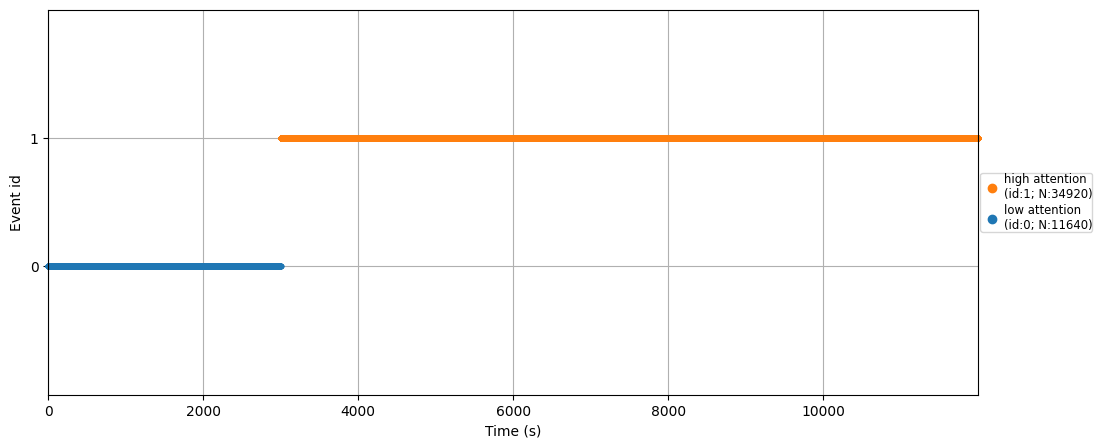

X: (46560, 12, 128) (эпохи, каналы, время)
y: (46560,) (метки классов)


In [4]:
file_path = r'epochs\sam40_full_epochs.zip'
sam40_X, sam40_y  = load_epochs_to_numpy(file_path)

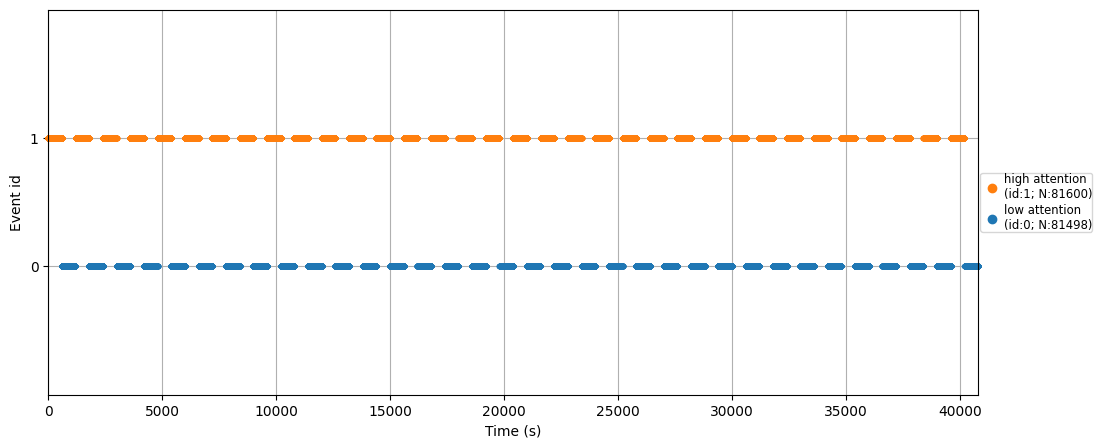

X: (163098, 12, 128) (эпохи, каналы, время)
y: (163098,) (метки классов)


In [5]:
file_path = r'epochs\distinguishing_epochs.zip'
distinguish_X, distinguish_y = load_epochs_to_numpy(file_path)

# Feature Extraction

In [6]:
from mne_features.feature_extraction import extract_features


def extract_basic_eeg_features(X, y, label):
    sfreq = 128
    freq_bands = [
        (0.5, 4),   # delta
        (4, 8),     # theta
        (8, 13),    # alpha
        (13, 30),   # beta
        (30, 45)    # gamma
    ]
    
    selected_features = [
        'pow_freq_bands',
        'higuchi_fd',
        'katz_fd'
    ]
    
    initial_shape = X.shape

    # Извлекаем признаки
    new_X = extract_features(
        X, sfreq=sfreq,
        selected_funcs=selected_features,
        funcs_params={
            'pow_freq_bands__freq_bands': freq_bands,
            'pow_freq_bands__log': True
        }
    )

    # Выводим информацию
    print(f'{label}:')
    print(f'  X исходная: {initial_shape} (эпохи, каналы, время)')
    print(f'  X после fe: {new_X.shape} (эпохи, признаки)')
    print(f'  y: {y.shape} (метки классов)')
    
    return new_X

In [7]:
sam40_X = extract_basic_eeg_features(sam40_X, sam40_y,'SAM40')

SAM40:
  X исходная: (46560, 12, 128) (эпохи, каналы, время)
  X после fe: (46560, 84) (эпохи, признаки)
  y: (46560,) (метки классов)


In [8]:
distinguish_X = extract_basic_eeg_features(distinguish_X, distinguish_y,'Distinguishing')

Distinguishing:
  X исходная: (163098, 12, 128) (эпохи, каналы, время)
  X после fe: (163098, 84) (эпохи, признаки)
  y: (163098,) (метки классов)


# GridSearch

In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV



param_grid = {
    'n_estimators': [100, 300, 500, 700],
    'learning_rate': [0.01, 0.1, 0.3, 0.5],
    'max_depth': [3, 5, 7],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}


estimator = xgb.XGBClassifier(       
    objective='binary:logistic',
    eval_metric='logloss',      
    random_state=42            
)


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=estimator,
    param_grid=param_grid,
    scoring='accuracy',
    cv=skf,
    verbose=1,
    n_jobs=-1 # Используем все доступные ядра
)


grid_search.fit(
    distinguish_X,
    distinguish_y,
    verbose=False
)

# Выводим результаты
print("Лучшие параметры:", grid_search.best_params_)
print("Лучший Accuracy на кросс-валидации:", grid_search.best_score_)

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 700, 'subsample': 0.8}
Лучший Accuracy на кросс-валидации: 0.7570908466662527


Fitting 5 folds for each of 144 candidates, totalling 720 fits
Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 700, 'subsample': 0.8}
Лучший Accuracy на кросс-валидации: 0.7570908466662527

In [21]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV



param_grid = {
    'n_estimators': [100, 300, 500, 700],
    'learning_rate': [0.01, 0.1, 0.3, 0.5],
    'max_depth': [3, 4, 5, 6, 7],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}


estimator = xgb.XGBClassifier(       
    objective='binary:logistic',
    eval_metric='logloss',      
    random_state=42            
)


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=estimator,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=skf,
    verbose=1,
    n_jobs=-1 # Используем все доступные ядра
)


grid_search.fit(
    sam40_X,
    sam40_y,
    verbose=False
)

# Выводим результаты
print("Лучшие параметры:", grid_search.best_params_)
print("Лучший roc_auc на кросс-валидации:", grid_search.best_score_)

Fitting 5 folds for each of 720 candidates, totalling 3600 fits
Лучшие параметры: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 700, 'subsample': 0.8}
Лучший roc_auc на кросс-валидации: 0.752584890894455


Fitting 5 folds for each of 144 candidates, totalling 720 fits
Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 700, 'subsample': 0.8}
Лучший Accuracy на кросс-валидации: 0.7570908466662527